# Notebook de Métricas Estruturais de PDFs

Este notebook gera grafos estruturais para cada PDF, calcula métricas de similaridade (Jaccard, kernel WL normalizado). Há suporte para análises em grafos maiores (até milhares de nós) com o uso do kernel WL, além de visualizações estáticas e interativas dos grafos resultantes.



In [1]:
import os
import re
import json
import time
from io import BytesIO
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout
import matplotlib.pyplot as plt
import seaborn as sns

from pypdf import PdfReader
from pypdf.generic import (
    IndirectObject,
    DictionaryObject,
    StreamObject,
    ArrayObject,
    NameObject,
)
from pdfminer.pdfparser import PDFParser
from pdfminer.pdfdocument import PDFDocument
from pdfminer.pdftypes import resolve1



In [2]:
PDFMINER_CALLS = 0
PDFMINER_ACCUM = 0.0
OBJ_VISITED = 0
LARGE_STREAM_COUNT = 0


def reset_profiling_metrics():
    global PDFMINER_CALLS, PDFMINER_ACCUM, OBJ_VISITED, LARGE_STREAM_COUNT
    PDFMINER_CALLS = 0
    PDFMINER_ACCUM = 0.0
    OBJ_VISITED = 0
    LARGE_STREAM_COUNT = 0



### Extração de Estruturas PDF

Iniciamos lendo o arquivo com `PyPDF` para percorrer a árvore de objetos indiretos e, opcionalmente, consultamos o `pdfminer.six` para inspecionar alguns dicionários menores. Para manter o processamento viável em PDFs grandes, reutilizamos um único parser do pdfminer, aplicamos cache simples e ignoramos streams muito volumosos (por exemplo imagens comprimidas). O grafo resultante representa cada objeto indireto como nó e as referências entre objetos como arestas, servindo de base para as métricas de similaridade.


In [3]:
MAX_DEPTH = 1000
PDFMINER_STREAM_LENGTH_LIMIT = 50_000
PDFMINER_MAX_DICT_ENTRIES = 80


def parse_pdf_structure(file_path):
    reset_profiling_metrics()

    pdfminer_document = None
    pdfminer_cache = {}
    try:
        pdf_bytes = Path(file_path).read_bytes()
        pdfminer_buffer = BytesIO(pdf_bytes)
        pdfminer_parser = PDFParser(pdfminer_buffer)
        pdfminer_document = PDFDocument(pdfminer_parser)
        if not getattr(pdfminer_document, "is_extractable", False):
            print("[profiling] PDF não permite extração; ignorando pdfminer", flush=True)
            pdfminer_document = None
    except Exception as exc:  # noqa: BLE001
        print(f"[profiling] Falha ao inicializar pdfminer: {exc}", flush=True)
        pdfminer_document = None

    with open(file_path, "rb") as file:
        reader = PdfReader(file)
        trailer = reader.trailer

        graph = nx.DiGraph()
        graph.add_node("trailer", label="trailer")
        processed = set()

        process_references(
            trailer,
            "trailer",
            0,
            graph,
            reader,
            processed,
            pdfminer_document,
            pdfminer_cache,
        )

    print(
        f"[profiling] objetos visitados={OBJ_VISITED}, chamadas pdfminer={PDFMINER_CALLS}, "
        f"tempo pdfminer={PDFMINER_ACCUM:.2f}s, streams grandes={LARGE_STREAM_COUNT}",
        flush=True,
    )
    return graph

def find_key(obj, ref_num, key):
    if isinstance(obj, DictionaryObject):
        for k, v in obj.items():
            if isinstance(v, IndirectObject) and v.idnum == ref_num:
                key = k
            elif isinstance(v, DictionaryObject):
                key = find_key(v, ref_num, key)
    return key

def should_use_pdfminer(obj):
    if not isinstance(obj, DictionaryObject):
        return False
    if isinstance(obj, StreamObject):
        length_value = obj.get("/Length")
        if isinstance(length_value, IndirectObject):
            length_value = length_value.get_object()
        if isinstance(length_value, (int, float)) and length_value > PDFMINER_STREAM_LENGTH_LIMIT:
            return False
    if len(obj.keys()) > PDFMINER_MAX_DICT_ENTRIES:
        return False
    return True

def process_references(
    obj,
    parent_label,
    num_obj,
    graph,
    reader,
    processed,
    pdfminer_document,
    pdfminer_cache,
    depth=0,
    force_third_level=False,
):
    if depth > MAX_DEPTH:
        return

    global OBJ_VISITED, PDFMINER_CALLS, PDFMINER_ACCUM, LARGE_STREAM_COUNT

    if isinstance(obj, IndirectObject):
        obj = obj.get_object()

    obj_id = id(obj)
    if obj_id in processed:
        return
    processed.add(obj_id)

    OBJ_VISITED += 1
    if OBJ_VISITED % 200 == 0:
        print(f"[profiling] {OBJ_VISITED} objetos visitados", flush=True)

    content = obj.__repr__()
    references = re.findall(r"(IndirectObject)\((\d+), (\d+),", content)

    use_pdfminer = (
        pdfminer_document is not None
        and num_obj != 0
        and should_use_pdfminer(obj)
    )

    if use_pdfminer and isinstance(obj, StreamObject):
        length_value = obj.get("/Length")
        if isinstance(length_value, IndirectObject):
            length_value = length_value.get_object()
        if isinstance(length_value, (int, float)) and length_value > PDFMINER_STREAM_LENGTH_LIMIT:
            LARGE_STREAM_COUNT += 1
            use_pdfminer = False
            print(
                f"[profiling] stream grande detectado (len={length_value}) no obj {num_obj}, pulando pdfminer",
                flush=True,
            )

    if use_pdfminer:
        try:
            start_time = time.perf_counter()
            content_miner = extract_indirect_object_content(pdfminer_document, pdfminer_cache, num_obj)
            elapsed = time.perf_counter() - start_time
            PDFMINER_CALLS += 1
            PDFMINER_ACCUM += elapsed
            if PDFMINER_CALLS % 25 == 0:
                print(
                    f"[profiling] pdfminer chamadas={PDFMINER_CALLS}, tempo acumulado={PDFMINER_ACCUM:.2f}s",
                    flush=True,
                )
            if content_miner is not None:
                references_additional = re.findall(r"([a-zA-Z]+)\': <PDFObjRef:(\d+)(>)", str(content_miner))
                references.extend(references_additional)
        except Exception as exc:  # noqa: BLE001
            print(f"Erro ao extrair conteúdo com pdfminer: {exc}")

    for ref in references:
        ref_num = int(ref[1])
        child_label = f"obj_{ref_num}"
        if isinstance(reader.get_object(ref_num), DictionaryObject):
            obj_child = reader.get_object(ref_num)
            child_type = obj_child.get("/Type", "void")
        else:
            child_type = "void"

        if child_type == "/StructTreeRoot":
            node_label = f"{ref_num}_{child_type}"
            if child_label not in graph:
                graph.add_node(child_label, label=node_label)
            graph.add_edge(parent_label, child_label, key="StructTreeRoot")
            continue

        node_label = f"{ref_num}_{child_type}"
        if child_label not in graph:
            graph.add_node(child_label, label=node_label)

        key = None
        key = find_key(obj, ref_num, key)
        if key is None:
            key = ref[0]

        if force_third_level and depth == 1:
            intermediate_label = f"intermediate_{parent_label}"
            if intermediate_label not in graph:
                graph.add_node(intermediate_label, label=intermediate_label)
                graph.add_edge(parent_label, intermediate_label)
            graph.add_edge(intermediate_label, child_label, key=key)
        else:
            graph.add_edge(parent_label, child_label, key=key)

        next_force = force_third_level
        if isinstance(obj, DictionaryObject) and obj.get("/Type") == "/Pages":
            next_force = True

        process_references(
            IndirectObject(ref_num, 0, reader),
            child_label,
            ref_num,
            graph,
            reader,
            processed,
            pdfminer_document,
            pdfminer_cache,
            depth + 1,
            next_force,
        )

def extract_indirect_object_content(pdfminer_document, cache, obj_num):
    if pdfminer_document is None:
        return None
    if obj_num in cache:
        return cache[obj_num]

    obj_ref = pdfminer_document.getobj(obj_num)
    resolved_obj = resolve1(obj_ref)

    if isinstance(resolved_obj, StreamObject):
        length_value = resolved_obj.get("/Length")
        if isinstance(length_value, IndirectObject):
            length_value = length_value.get_object()
        print(
            f"[profiling] processando stream obj {obj_num} com length={length_value}",
            flush=True,
        )
        if isinstance(length_value, (int, float)) and length_value > PDFMINER_STREAM_LENGTH_LIMIT:
            LARGE_STREAM_COUNT += 1
            cache[obj_num] = None
            return None

    if isinstance(resolved_obj, bytes):
        content = resolved_obj.decode("latin1", errors="ignore")
    elif isinstance(resolved_obj, dict):
        content = {k: (v.decode("latin1") if isinstance(v, bytes) else v) for k, v in resolved_obj.items()}
    else:
        content = str(resolved_obj)

    cache[obj_num] = content
    return content



In [4]:
def visualize_graph(graph, output_image, pdf_label):
    plt.figure(figsize=(15, 12))
    pos = graphviz_layout(graph, prog="dot", args="-Grankdir=TB -Gnodesep=150 -Granksep=150")
    node_labels = nx.get_node_attributes(graph, "label")
    edge_labels = nx.get_edge_attributes(graph, "key")
    nx.draw(
        graph,
        pos,
        labels=node_labels,
        with_labels=True,
        node_size=1600,
        node_color="lightblue",
        font_size=8,
        font_weight="bold",
        arrows=True,
        arrowstyle="-|>",
        arrowsize=16,
    )
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=7)
    plt.title(f"Legenda: {pdf_label}", fontsize=16, fontweight="bold")
    plt.savefig(output_image, format="PNG", bbox_inches="tight")
    plt.show()


def visualize_graph_3d(graph, output_html):
    from pyvis.network import Network

    net = Network(height="1200px", width="100%", notebook=True, cdn_resources="in_line", directed=True)

    for node, data in graph.nodes(data=True):
        net.add_node(node, label=data.get("label", str(node)), title=data.get("label", str(node)))

    for source, target, data in graph.edges(data=True):
        net.add_edge(source, target, title=data.get("key", ""))

    net.show_buttons(filter_=["physics", "interaction", "layout"])
    net.show(output_html)



In [5]:
def get_pdf_files_from_folder(folder_path):
    pdf_files = []
    for root, _dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(".pdf"):
                pdf_files.append(os.path.join(root, file))
    return sorted(pdf_files)



In [6]:
def jaccard_similarity(set1, set2):
    if not set1 and not set2:
        return 1.0
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    if union == 0:
        return 0.0
    return intersection / union



### Métrica Weisfeiler–Lehman (WL)

Aplicamos o refinamento de rótulos WL para capturar padrões de vizinhança. A cada iteração, cada nó concatena seu rótulo ao multiconjunto dos rótulos dos vizinhos, gerando novas etiquetas. A matriz kernel resultante deriva do produto interno dessas contagens, normalizado para produzir valores entre 0 e 1.


In [7]:
def build_wl_feature_matrix(graphs, iterations=3):
    feature_dicts = []
    feature_set = set()

    for graph in graphs:
        features = weisfeiler_lehman_features(graph, iterations=iterations)
        feature_dicts.append(features)
        feature_set.update(features.keys())

    feature_list = sorted(feature_set)
    if not feature_list:
        return np.zeros((len(graphs), 0)), feature_list

    matrix = np.zeros((len(graphs), len(feature_list)), dtype=float)
    for i, features in enumerate(feature_dicts):
        for j, feature in enumerate(feature_list):
            matrix[i, j] = features.get(feature, 0)

    return matrix, feature_list


def compute_wl_kernel(graphs, iterations=3):
    feature_matrix, feature_names = build_wl_feature_matrix(graphs, iterations=iterations)
    if feature_matrix.size == 0:
        n = len(graphs)
        return np.ones((n, n)), feature_names

    kernel = feature_matrix @ feature_matrix.T
    diagonal = np.diag(kernel)
    norms = np.sqrt(np.clip(diagonal, a_min=1e-12, a_max=None))
    normalization = np.outer(norms, norms)
    normalized_kernel = np.divide(kernel, normalization, out=np.zeros_like(kernel), where=normalization != 0)
    return normalized_kernel, feature_names



In [8]:
def weisfeiler_lehman_features(graph, iterations=3):
    if isinstance(graph, nx.DiGraph):
        working_graph = graph.to_undirected()
    else:
        working_graph = graph.copy()

    labels = {node: data.get("label", str(node)) for node, data in working_graph.nodes(data=True)}
    feature_counter = Counter(labels.values())

    for _ in range(iterations):
        new_labels = {}
        for node in working_graph.nodes():
            neighbors = sorted(labels[neighbor] for neighbor in working_graph.neighbors(node))
            new_label = labels[node] + "|" + "-".join(neighbors)
            new_labels[node] = new_label
        labels = new_labels
        feature_counter.update(labels.values())

    return feature_counter



### Métrica de Similaridade de Jaccard

Usamos a sobreposição de rótulos de nós e arestas para comparar dois grafos: a pontuação é a razão entre a interseção e a união desses conjuntos. Essa métrica destaca objetos e referências comuns, sem considerar profundidade ou vizinhança além do rótulo associado.


In [9]:
def graph_jaccard_similarity(graph1, graph2):
    node_labels_1 = {data.get("label", str(node)) for node, data in graph1.nodes(data=True)}
    node_labels_2 = {data.get("label", str(node)) for node, data in graph2.nodes(data=True)}
    node_sim = jaccard_similarity(node_labels_1, node_labels_2)

    edge_labels_1 = {
        (graph1.nodes[u].get("label", str(u)), graph1.nodes[v].get("label", str(v)), data.get("key", ""))
        for u, v, data in graph1.edges(data=True)
    }
    edge_labels_2 = {
        (graph2.nodes[u].get("label", str(u)), graph2.nodes[v].get("label", str(v)), data.get("key", ""))
        for u, v, data in graph2.edges(data=True)
    }
    edge_sim = jaccard_similarity(edge_labels_1, edge_labels_2)

    return (node_sim + edge_sim) / 2



In [10]:
def compute_similarity_matrices(pdf_files, graphs, wl_kernel_matrix=None):
    n = len(pdf_files)
    jaccard_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i, n):
            score = graph_jaccard_similarity(graphs[i], graphs[j])
            jaccard_matrix[i, j] = jaccard_matrix[j, i] = score

    result = {
        "jaccard": jaccard_matrix,
    }
    if wl_kernel_matrix is not None:
        result["wl_kernel"] = wl_kernel_matrix
    return result



In [11]:
# Caminho para a pasta de PDFs
folder_path = "./docs"

pdf_files = get_pdf_files_from_folder(folder_path)
pdf_files


['./docs/SEI_08201.000182_2022_88 - Documento 1.pdf',
 './docs/SEI_08201.000182_2022_88 - Documento 2.pdf']

In [12]:
graphs = []

for pdf in pdf_files:
    print(f"Processando {pdf}")
    graph = parse_pdf_structure(pdf)
    graphs.append(graph)

len(graphs)


Processando ./docs/SEI_08201.000182_2022_88 - Documento 1.pdf
[profiling] objetos visitados=16, chamadas pdfminer=15, tempo pdfminer=18.20s, streams grandes=0
Processando ./docs/SEI_08201.000182_2022_88 - Documento 2.pdf
[profiling] objetos visitados=23, chamadas pdfminer=22, tempo pdfminer=0.02s, streams grandes=0


2

In [15]:
wl_kernel_matrix, wl_feature_names = compute_wl_kernel(graphs, iterations=3)
wl_kernel_matrix.shape


(2, 2)

In [16]:
wl_feature_names[:10] if wl_feature_names else []



['10_void',
 '10_void|6_/Page',
 '10_void|6_/Page|6_/Page|10_void-11_void-12_void-2_/Pages-8_void-9_void',
 '10_void|6_/Page|6_/Page|10_void-11_void-12_void-2_/Pages-8_void-9_void|6_/Page|10_void-11_void-12_void-2_/Pages-8_void-9_void|10_void|6_/Page-11_void|6_/Page-12_void|6_/Page-2_/Pages|1_/Catalog-6_/Page-7_/Page-8_void|3_/Outlines-6_/Page-9_void|17_/XObject-18_void-6_/Page',
 '10_void|6_/Page|6_/Page|10_void-11_void-2_/Pages-7_void-8_void-9_void',
 '10_void|6_/Page|6_/Page|10_void-11_void-2_/Pages-7_void-8_void-9_void|6_/Page|10_void-11_void-2_/Pages-7_void-8_void-9_void|10_void|6_/Page-11_void|12_/XObject-13_void-6_/Page-2_/Pages|1_/Catalog-6_/Page-7_void|3_/Outlines-6_/Page-8_void|6_/Page-9_void|6_/Page',
 '11_void',
 '11_void|12_/XObject-13_void-6_/Page',
 '11_void|12_/XObject-13_void-6_/Page|12_/XObject|11_void-14_void-13_void|11_void-15_/Font-6_/Page|10_void-11_void-2_/Pages-7_void-8_void-9_void',
 '11_void|12_/XObject-13_void-6_/Page|12_/XObject|11_void-14_void-13_void|11_vo

In [17]:
results = compute_similarity_matrices(
    pdf_files,
    graphs,
    wl_kernel_matrix=wl_kernel_matrix,
)
results.keys()


dict_keys(['jaccard', 'wl_kernel'])

In [18]:
labels = [f"PDF {i+1}" for i in range(len(pdf_files))]

similarity_matrices_df = {
    name: pd.DataFrame(matrix, columns=labels, index=labels)
    for name, matrix in results.items()
}

similarity_matrices_df


{'jaccard':           PDF 1     PDF 2
 PDF 1  1.000000  0.355263
 PDF 2  0.355263  1.000000,
 'wl_kernel':           PDF 1     PDF 2
 PDF 1  1.000000  0.286707
 PDF 2  0.286707  1.000000}

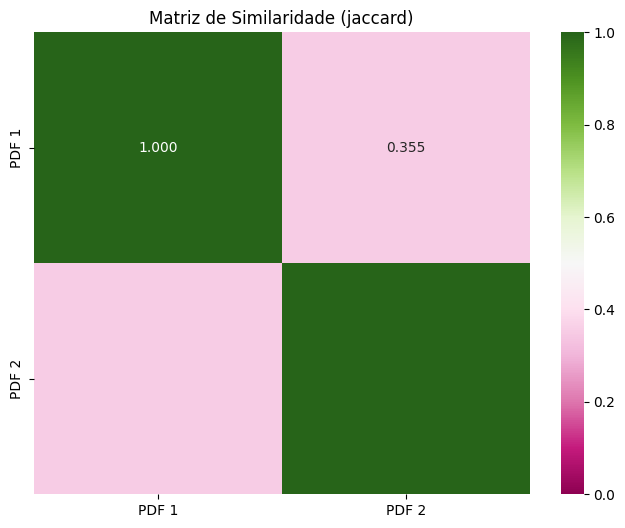

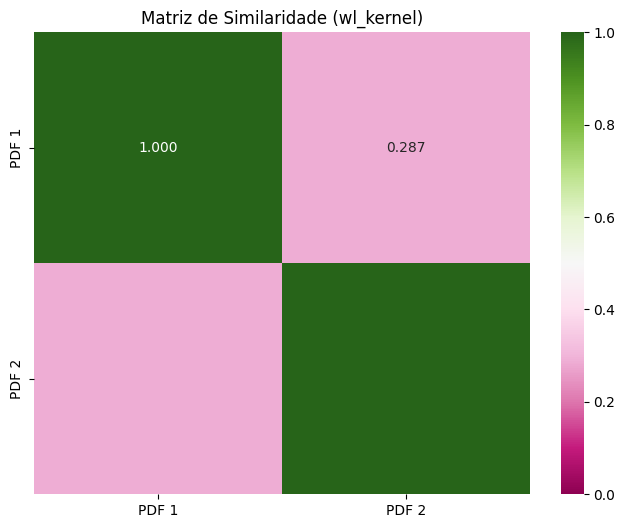

In [19]:
for name, df_matrix in similarity_matrices_df.items():
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_matrix, annot=True, fmt=".3f", cmap="PiYG", vmin=0, vmax=1)
    plt.title(f"Matriz de Similaridade ({name})")
    plt.show()



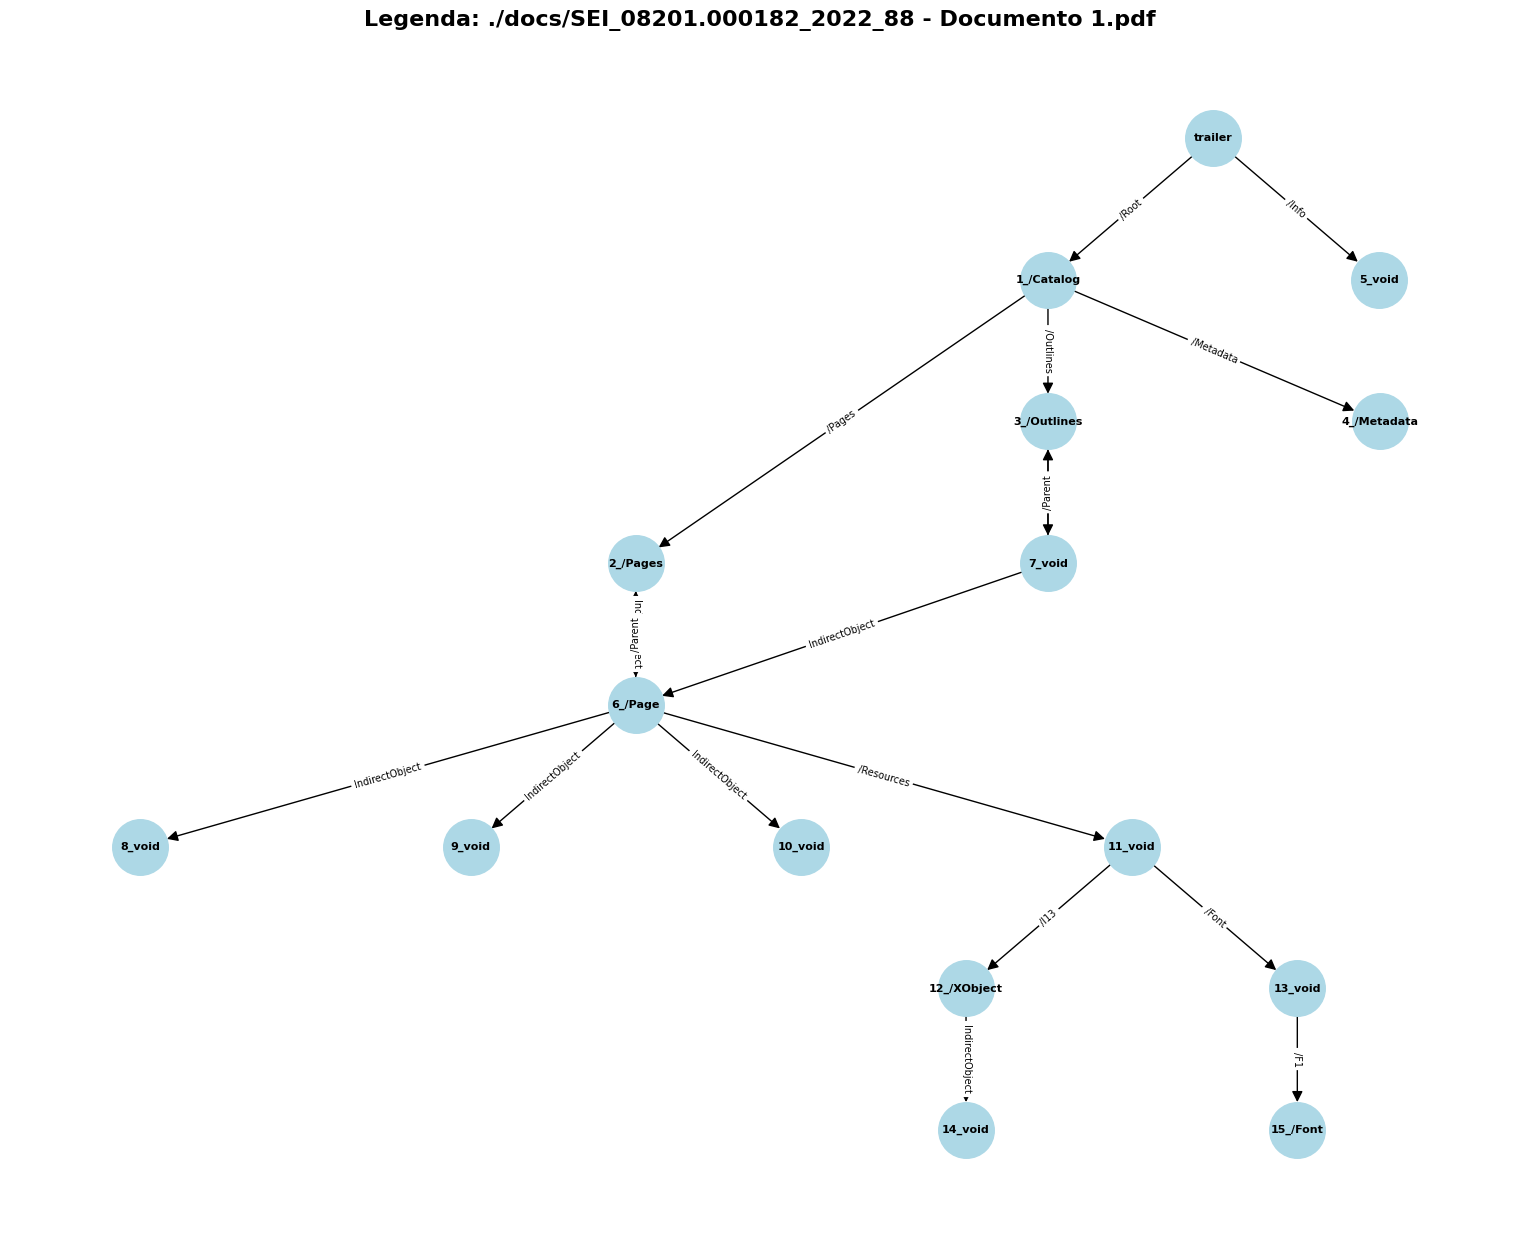

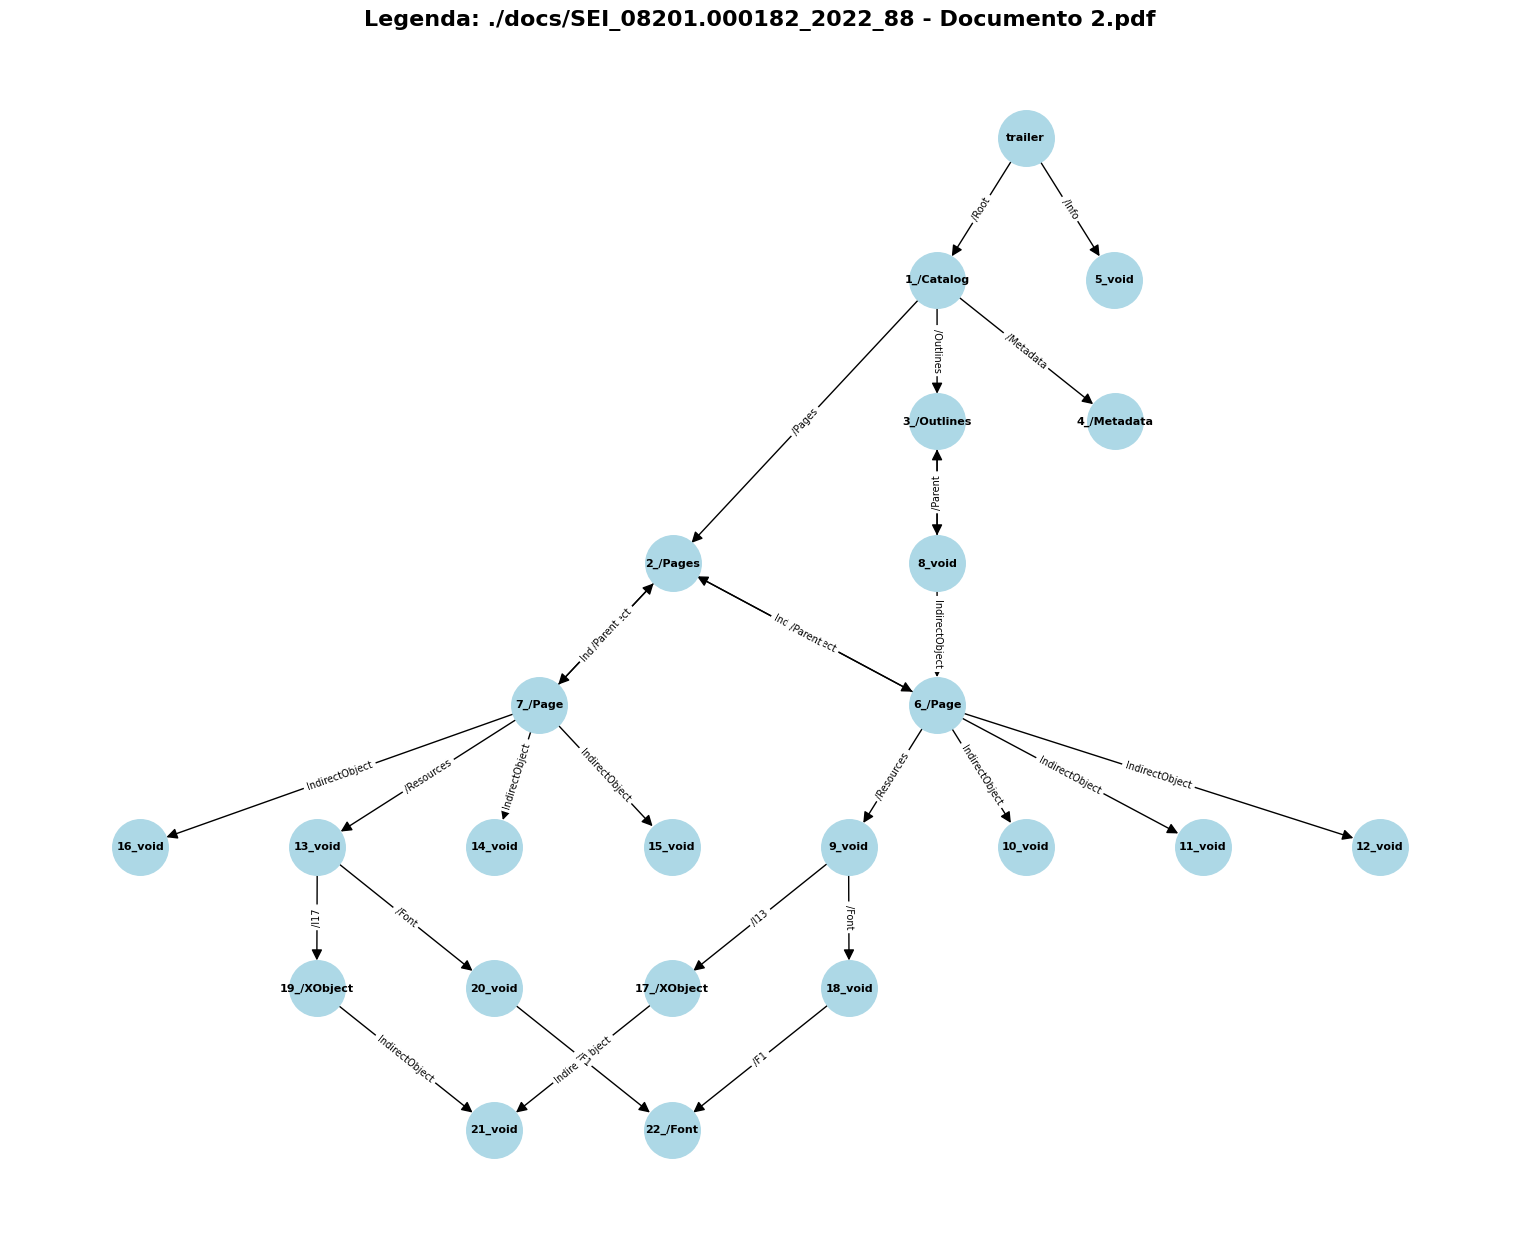

In [20]:
output_images = [f"{pdf}_grafo_metricas.png" for pdf in pdf_files]
for pdf, graph, output in zip(pdf_files, graphs, output_images):
    visualize_graph(graph, output, pdf)



In [21]:
for pdf, graph in zip(pdf_files, graphs):
    html_output = f"{pdf}_grafo_metricas.html"
    visualize_graph_3d(graph, html_output)



./docs/SEI_08201.000182_2022_88 - Documento 1.pdf_grafo_metricas.html
./docs/SEI_08201.000182_2022_88 - Documento 2.pdf_grafo_metricas.html
